In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

In [2]:
# Define consistent color palette for the entire analysis
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Gender color mapping for easy reference
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE,
    'Combined': COLOR_COMBINED
}

# Detailed analysis of time during the exam. expexted time vs. time taken task by task + by gender. see if time taken by task affects performance during each task.

In this part we performe the analysis only on students without extra or incident time.

## 1. Data Loading

In [3]:
df = load_data("../data/cleaned_data/IN2120_2024_cleaned_data.csv")
df.head()

Data loaded successfully from ../data/cleaned_data/IN2120_2024_cleaned_data.csv


,exam_start_time,exam_end_time,extra_time_mins,incident_time_mins,gender,student_id,final_grade_date,final_grade,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,candidate_response_code,candidate_response_text,total_score
0,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_1370871167225,konfidensialitet,67.5
1,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_IA17313295674742d674d25-c722-4a92...,tilgjengelighet,67.5
2,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_IA173132962912484243f1a-833f-47fb...,integritet,67.5
3,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,2,1.2,Oversettelse,30,2.0,simpleAssociableChoice_IA173100234618194d062e4...,simpleAssociableChoice_IA173100234618194d062e4...,67.5
4,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,2,1.2,Oversettelse,30,2.0,simpleAssociableChoice_1373281683440 simpleAss...,simpleAssociableChoice_1373281683440 simpleAss...,67.5


## 2. Data Preparation

In [4]:
df_time = df.groupby(['student_id', 'question_number']).agg({
    'gender': 'first',
    'max_question_score': 'first',
    'auto_score_per_question': 'first',
    'question_duration_sec': 'first',
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'extra_time_mins': 'first',
    'incident_time_mins': 'first',
    'total_score': 'first'
}).reset_index()

df_time['time_taken_exam_min'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)
df_time = df_time.drop(columns=['exam_start_time', 'exam_end_time'])

df_time['expected_time_per_question_sec'] = 144 * df_time['max_question_score']  # Assuming 144 sec (2.4 minutes) per point since total exam time is 240 minutes for 100 points

df_time.head()

,student_id,question_number,gender,max_question_score,auto_score_per_question,question_duration_sec,extra_time_mins,incident_time_mins,total_score,time_taken_exam_min,expected_time_per_question_sec
0,1,1.10,M,3,3.0,38,0,0,45.0,105.57,432
1,1,1.11,M,1,1.0,49,0,0,45.0,105.57,144
2,1,1.12,M,3,1.0,181,0,0,45.0,105.57,432
3,1,1.13,M,3,2.0,31,0,0,45.0,105.57,432
4,1,1.20,M,2,2.0,31,0,0,45.0,105.57,288


## 3. Data exploration

In [5]:
extra_time_students_data = df_time[(df_time['extra_time_mins'] != 0) | (df_time['incident_time_mins'] != 0)]

extra_time_students_count = extra_time_students_data.groupby('student_id').agg({
    'extra_time_mins': 'first',
    'incident_time_mins': 'first'
}).reset_index()

counter1 = 0
counter2 = 0

for i in extra_time_students_count['extra_time_mins']:
    if i != 0:
        counter1 += 1

for i in extra_time_students_count['incident_time_mins']:
    if i != 0:
        counter2 += 1

print(f"There are {counter1} students with extra_time_mins (given before the exam).")
print(f"There are {counter2} students with incident_time_mins (given during the exam).")

There are 0 students with extra_time_mins (given before the exam).
There are 1 students with incident_time_mins (given during the exam).


In [6]:
# remove students with extra time or incident time
df_time = df_time[(df_time['extra_time_mins'] == 0) & (df_time['incident_time_mins'] == 0)]

In [7]:
# checking
print("After filtering:")
print(f"Students with extra_time_mins != 0: {len(df_time[df_time['extra_time_mins'] != 0])}")
print(f"Students with incident_time_mins != 0: {len(df_time[df_time['incident_time_mins'] != 0])}")
print(f"Total students remaining: {df_time['student_id'].nunique()}")

After filtering:
Students with extra_time_mins != 0: 0
Students with incident_time_mins != 0: 0
Total students remaining: 366


In [8]:
# description and exploration of spesific columns in df_time
df_time[['time_taken_exam_min']].describe()

,time_taken_exam_min
count,13542.000000
mean,139.309262
std,49.476627
min,44.470000
25%,101.100000
50%,128.100000
75%,175.480000
max,270.530000


=== TIME OUTLIER ANALYSIS ===
Combined Time: 0 outliers (0.0%)
Male Time: 0 outliers (0.0%)
Female Time: 0 outliers (0.0%)


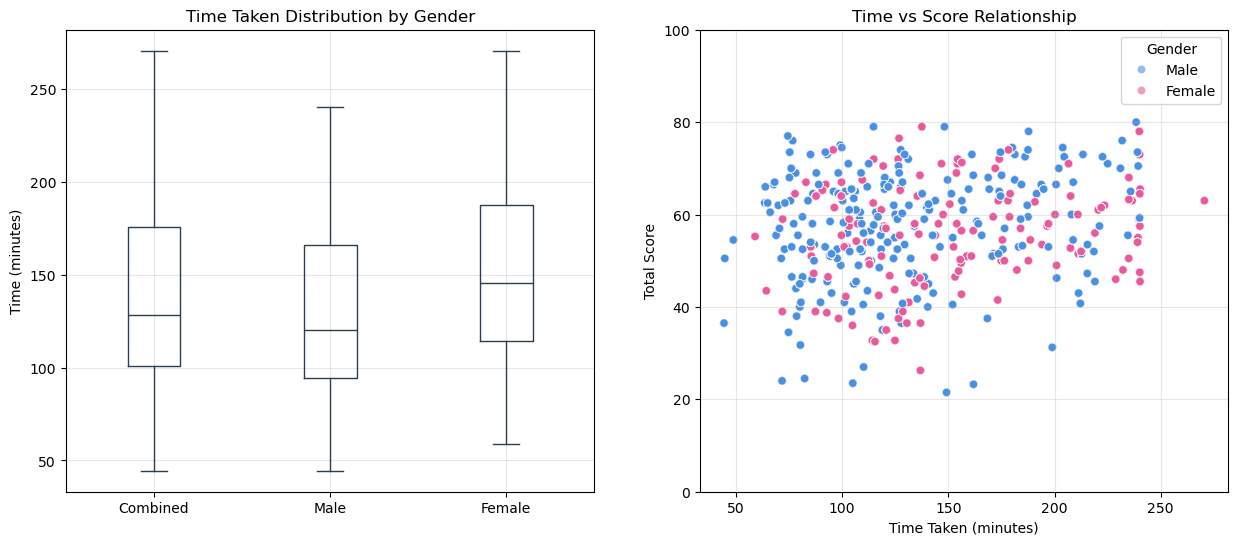

<Figure size 640x480 with 0 Axes>

In [9]:
# Enhanced time analysis visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Time taken boxplot
df_time_outliers = pd.DataFrame({
    'Combined': df_time['time_taken_exam_min'],
    'Male': df_time[df_time['gender'] == 'M']['time_taken_exam_min'],
    'Female': df_time[df_time['gender'] == 'F']['time_taken_exam_min']
})

df_time_outliers.boxplot(ax=axes[0], return_type='dict', color=COLOR_BOXPLOT)
axes[0].set_title("Time Taken Distribution by Gender")
axes[0].set_ylabel("Time (minutes)")
axes[0].grid(True, alpha=0.3)

# Identify outliers using IQR method
def identify_outliers(data, name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{name}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range: {outliers.min():.2f} - {outliers.max():.2f}")
    return outliers

# Time outlier analysis
print("=== TIME OUTLIER ANALYSIS ===")
time_combined_outliers = identify_outliers(df_time['time_taken_exam_min'], "Combined Time")
time_male_outliers = identify_outliers(df_time[df_time['gender'] == 'M']['time_taken_exam_min'], "Male Time")
time_female_outliers = identify_outliers(df_time[df_time['gender'] == 'F']['time_taken_exam_min'], "Female Time")

# Time vs Score relationship
sns.scatterplot(data=df_time, x='time_taken_exam_min', y='total_score', 
               hue='gender', alpha=0.6, ax=axes[1],
               palette={'F': COLOR_FEMALE, 'M': COLOR_MALE})
axes[1].set_title("Time vs Score Relationship")
axes[1].set_xlabel("Time Taken (minutes)")
axes[1].set_ylabel("Total Score")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

# Update legend labels for clarity - map the original labels to proper gender names
handles, labels = axes[1].get_legend_handles_labels()
# Create a mapping from the original labels (F/M) to full names
label_mapping = {'F': 'Female', 'M': 'Male'}
new_labels = [label_mapping.get(label, label) for label in labels]
axes[1].legend(handles, new_labels, title='Gender')

plt.show()
plt.tight_layout()

In [10]:
# description and exploration of spesific columns in df_time
df_time[['expected_time_per_question_sec', 'question_duration_sec']].describe()

,expected_time_per_question_sec,question_duration_sec
count,13542.000000,13542.000000
mean,389.189189,209.419805
std,247.993227,368.408665
min,144.000000,0.000000
25%,288.000000,55.000000
50%,288.000000,112.000000
75%,432.000000,223.000000
max,1440.000000,6132.000000


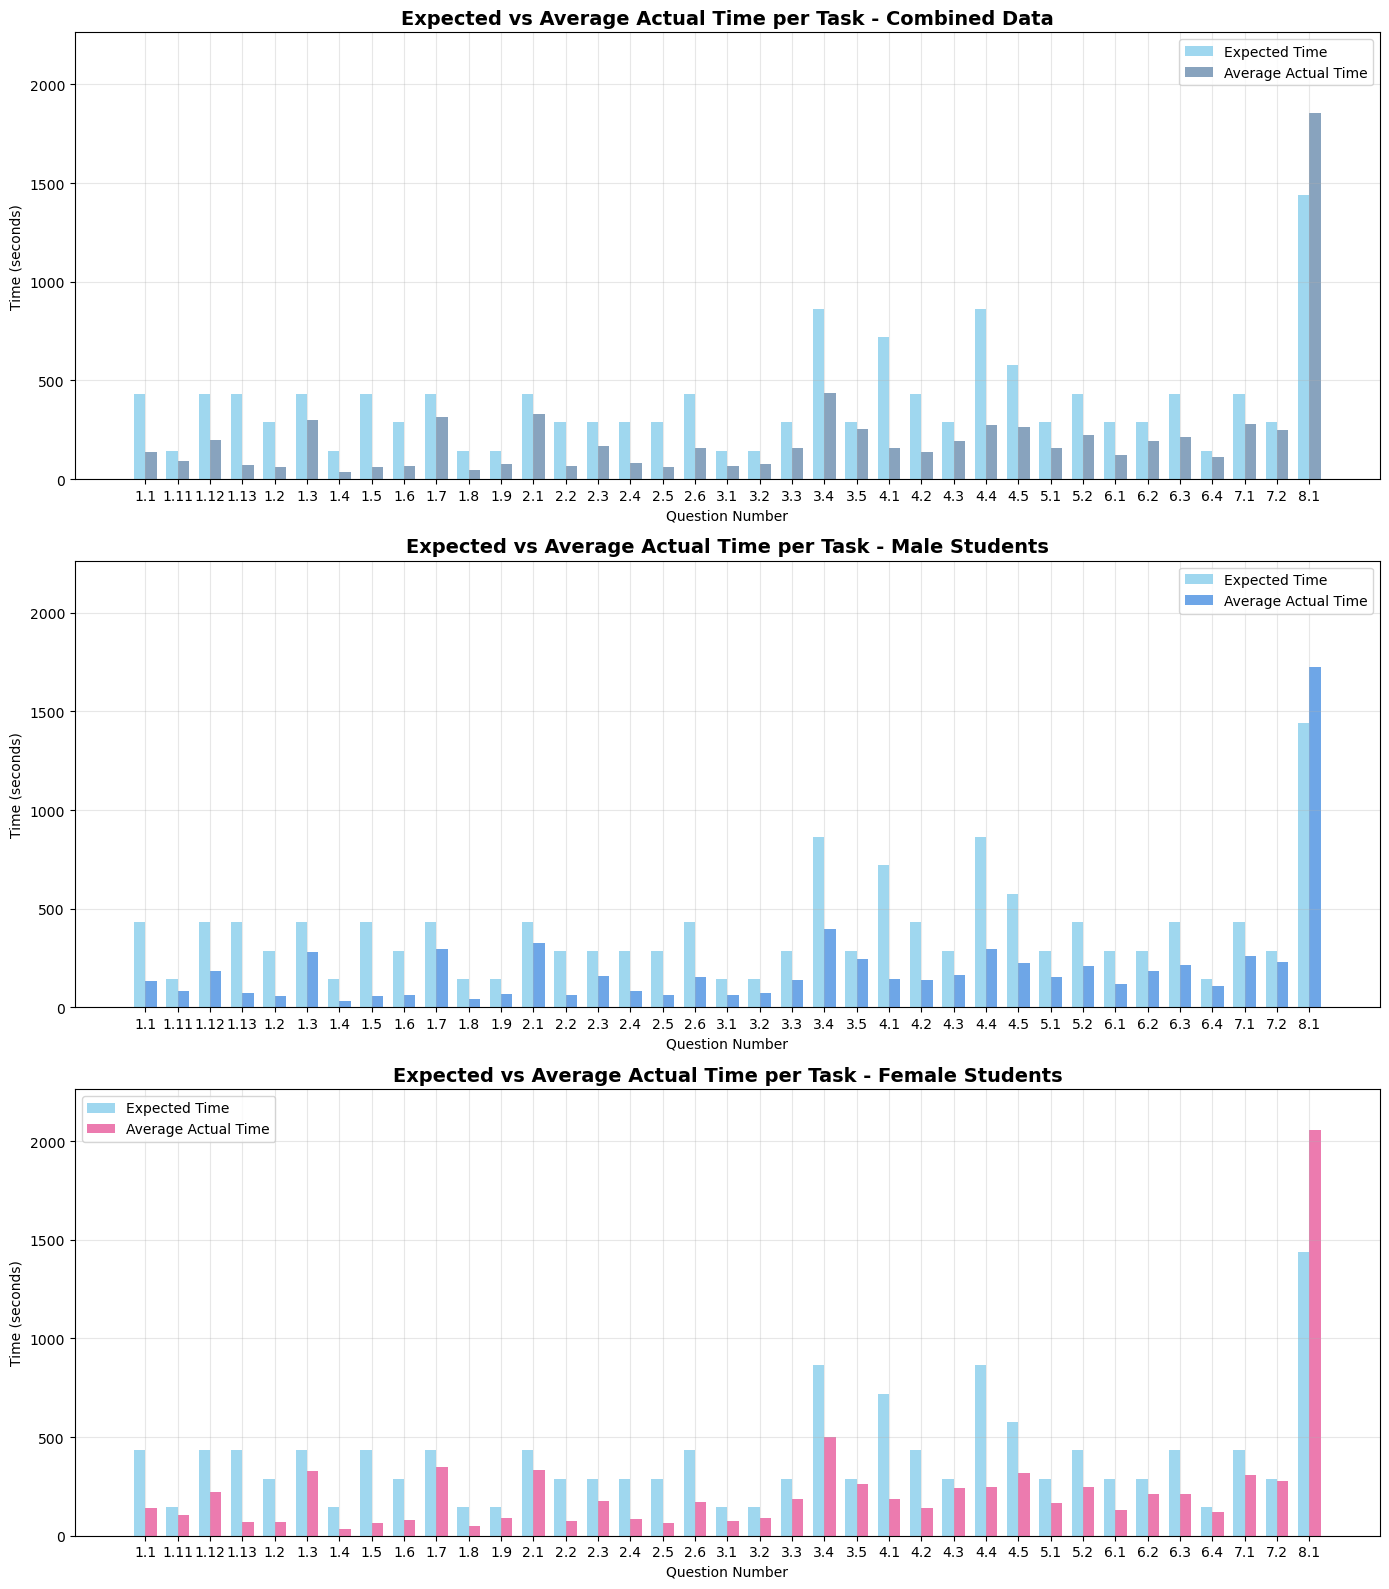

In [11]:
# Bar plots comparing expected vs actual time per task
# Calculate average time per question for each group
time_by_task = df_time.groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',  # Same for all students
    'question_duration_sec': 'mean'  # Average actual time
}).reset_index()

time_by_task_male = df_time[df_time['gender'] == 'M'].groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

time_by_task_female = df_time[df_time['gender'] == 'F'].groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

# Determine the maximum y-axis value for consistent scaling across all plots
max_expected = max(time_by_task['expected_time_per_question_sec'].max(),
                   time_by_task_male['expected_time_per_question_sec'].max(),
                   time_by_task_female['expected_time_per_question_sec'].max())
max_actual = max(time_by_task['question_duration_sec'].max(),
                 time_by_task_male['question_duration_sec'].max(),
                 time_by_task_female['question_duration_sec'].max())
y_max = max(max_expected, max_actual) * 1.1  # Add 10% padding

# Create the three plots
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Plot 1: Combined data
x = time_by_task['question_number']
width = 0.35
x_pos = range(len(x))

bars1 = axes[0].bar([i - width/2 for i in x_pos], time_by_task['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x_pos], time_by_task['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_COMBINED, alpha=0.8)

axes[0].set_xlabel('Question Number')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Expected vs Average Actual Time per Task - Combined Data', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x)
axes[0].set_ylim(0, y_max)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars1:
#     height = bar.get_height()
#     axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars2:
#     height = bar.get_height()
#     axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Plot 2: Male students
x_male = time_by_task_male['question_number']
x_pos_male = range(len(x_male))

bars3 = axes[1].bar([i - width/2 for i in x_pos_male], time_by_task_male['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars4 = axes[1].bar([i + width/2 for i in x_pos_male], time_by_task_male['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_MALE, alpha=0.8)

axes[1].set_xlabel('Question Number')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Expected vs Average Actual Time per Task - Male Students', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos_male)
axes[1].set_xticklabels(x_male)
axes[1].set_ylim(0, y_max)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars3:
#     height = bar.get_height()
#     axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars4:
#     height = bar.get_height()
#     axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Plot 3: Female students
x_female = time_by_task_female['question_number']
x_pos_female = range(len(x_female))

bars5 = axes[2].bar([i - width/2 for i in x_pos_female], time_by_task_female['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars6 = axes[2].bar([i + width/2 for i in x_pos_female], time_by_task_female['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_FEMALE, alpha=0.8)

axes[2].set_xlabel('Question Number')
axes[2].set_ylabel('Time (seconds)')
axes[2].set_title('Expected vs Average Actual Time per Task - Female Students', fontsize=14, fontweight='bold')
axes[2].set_xticks(x_pos_female)
axes[2].set_xticklabels(x_female)
axes[2].set_ylim(0, y_max)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars5:
#     height = bar.get_height()
#     axes[2].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars6:
#     height = bar.get_height()
#     axes[2].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()